# JAX based BCDI phase retrieval

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.42"   # ~20 GiB on a 48 GiB A40

import jax
import jax.numpy as jnp
print(jax.devices())

import numpy as np
import sys
import time 
import pynx
import cdiutils
import convexad_jax
from convexad_jax.optimize import *
from convexad_jax.viz import *
from convexad_jax.pynx_reconstruction import *
from scipy.fft import fftshift, ifftshift, fftn, ifftn


[CudaDevice(id=0)]


# Load data

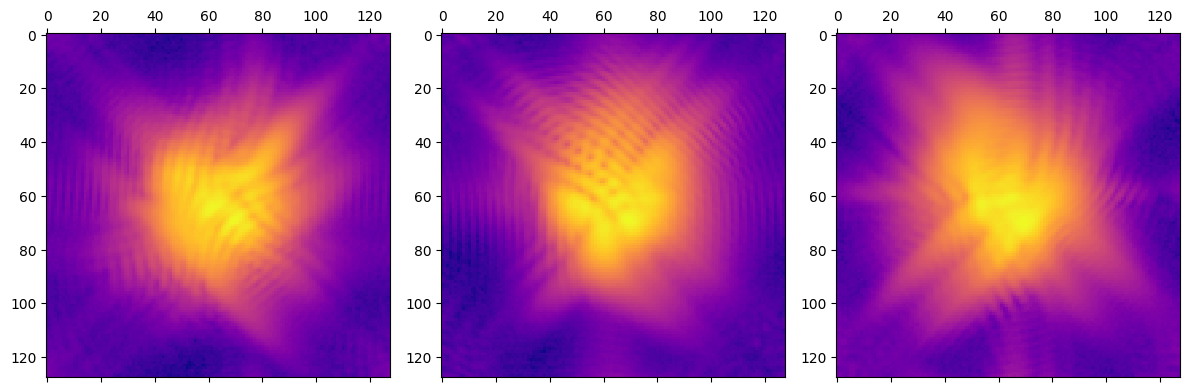

In [19]:
Iobs = np.load("../../ad_github/notebooks/data_prova.npz")["I"].astype(np.float32)
Iobs = np.load("../../paper/sim_tests/vary_phase_range/phase_range.npz")['Is'][9]
key = jax.random.PRNGKey(0)

plot_3D_projections(Iobs)

In [ ]:
# Solve PR

In [3]:
t0 = time.time()
result = reconstruct(
    key,
    Iobs,
    n_restarts = 32,
    N=128,
    size_factor=4.0,
    eps=0.9,
    alpha=0.0,
    beta=0.0,
    metric="mae",
    phase_type="displacement",
    phase_kwargs={'hkl': [2,2,2]},
    support_type="single",
    # support_kwargs={'M_parts': 3, 'N_per_part': 32},
    optimizer="adam",
    max_steps=1000,
    tol=1e-6,
    memory_size=10,
    learning_rate=0.05,
    grid_shape=None,
)
print(f"done in {time.time() - t0:.1f}s")

done in 109.4s


In [4]:
print("best loss:", float(result.best_loss))
print("steps per restart:", result.all_steps)


best loss: 0.11243923008441925
steps per restart: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000 1000 1000 1000 1000
 1000 1000 1000 1000 1000 1000 1000 1000 1000 1000 1000 1000 1000 1000
 1000 1000 1000 1000]


In [5]:
support, amplitude, phase = result.evaluate(Iobs)

modulus = amplitude*support
obj = modulus*phase[0] + 1.0j*modulus*phase[1]


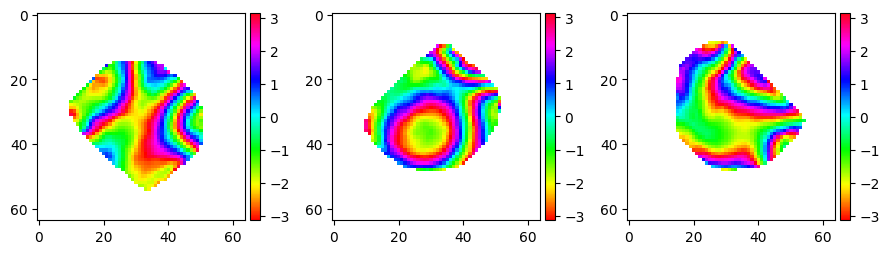

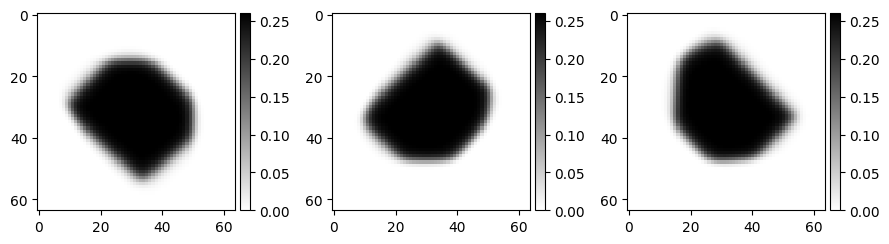

In [6]:
plot_2D_slices_middle_only_phase(obj, unwrap = False)
plot_2D_slices_middle_only_module(obj)

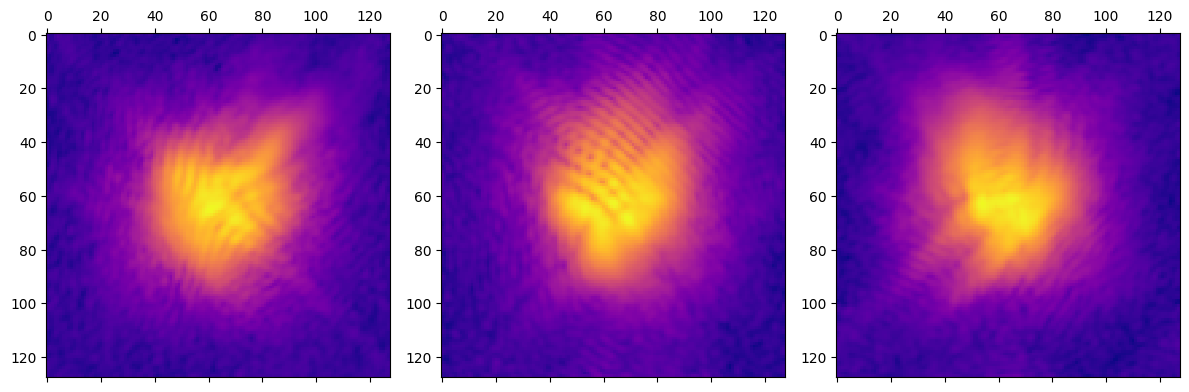

In [7]:
def _center_pad(obj, target_shape):
    pads = []
    for src, dst in zip(obj.shape, target_shape):
        delta = dst - src
        p0 = delta // 2
        p1 = delta - p0
        pads.append((p0, p1))
    return jnp.pad(obj, pads)
obj_p = _center_pad(obj, Iobs.shape)

Icalc = np.abs(ifftshift(fftn(fftshift(obj_p))))
plot_3D_projections(Icalc)

# PyNX refinement

In [8]:
from pynx.processing_unit import ProcessingUnit
pu = ProcessingUnit()
pu.select_gpu(language="cuda", verbose=True)

Computing speed for available CUDA GPU [ranking by global memory bandwidth]:
                                                  NVIDIA A40:   44 Gb,   523 Gbytes/s  [PCI: 0000:21:00.0]
Using CUDA GPU: NVIDIA A40


True

In [12]:
params = default_cdi_parameters()
params['obj_init'] = obj_p
params['support_threshold_relative'] = 0.25 # np.random.uniform(0.15,0.25)
params['support_update'] = 50
params['fix_support'] = False
params['algo_string'] = 'HIO_0 RAAR_00 ER_400'
params['support_update_border'] = True
params['support_update_border_n'] = 1
params['post_expand'] =(-1,1)
params['tv'] = 0.01
params['tv_er'] = 0.01
params['roi'] = 'full'
params['save_plot'] = False
params['plot_result']  = False

using gaussian convoluted and threshold as support
tv regularization at : 0.01


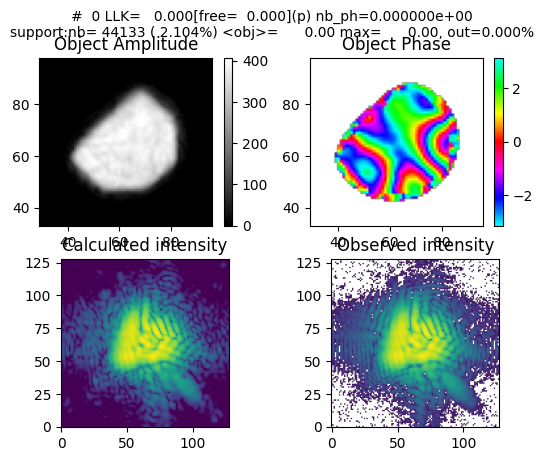

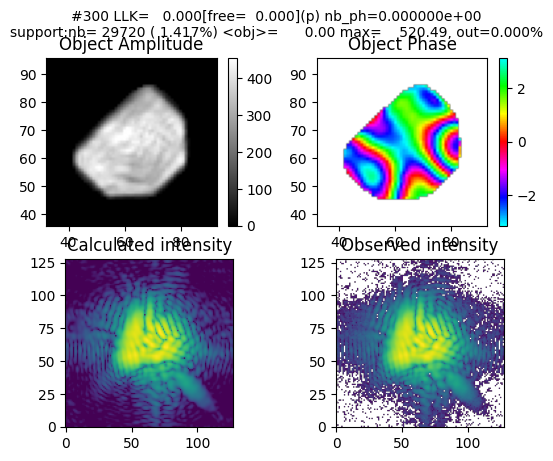

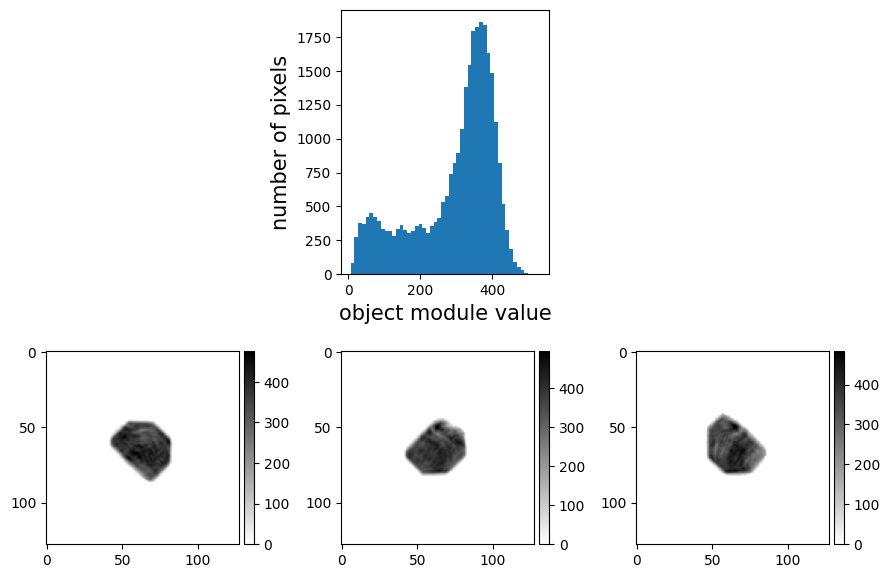

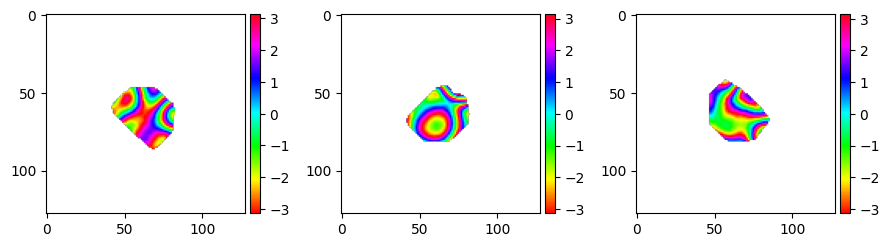

In [17]:
obj3d, llk, support, return_dict = CDI_one_reconstruction(Iobs, params)
Icalc = np.abs(ifftshift(fftn(fftshift(obj3d))))**2
plot_2D_slices_middle_only_module_and_histogram(obj3d)
plot_2D_slices_middle_only_phase(obj3d, threshold_module= .25, unwrap= False)

In [11]:
# np.savez('core_12_JAX_1.npz', obj = obj_p, data = Iobs)